# Лабораторная работа 2. Исследовательский анализ данных

**Вариант 14.** Набор данных `clients.csv` содержит сведения о клиентах магазина: идентификатор, год рождения, образование, семейное положение, доход семьи, количество детей, дату регистрации и количество покупок по акциям.

Цель работы — исследовать распределения и взаимосвязи признаков средствами pandas, matplotlib и seaborn.


## 1 Загрузка и предварительная обработка


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('clients.csv', sep=';')
df.info()
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 796 entries, 0 to 795
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 796 non-null    int64  
 1   Year_Birth         796 non-null    int64  
 2   Education          796 non-null    str    
 3   Marital_Status     796 non-null    str    
 4   Income             784 non-null    float64
 5   Kidhome            795 non-null    float64
 6   Dt_Customer        795 non-null    str    
 7   NumDealsPurchases  795 non-null    float64
dtypes: float64(3), int64(2), str(3)
memory usage: 49.9 KB


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Dt_Customer,NumDealsPurchases
count,796.000000,796.000000,796,796,784.00000,795.000000,795,795.000000
unique,NaN,NaN,4,8,NaN,NaN,469,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,02.01.2013,NaN
freq,NaN,NaN,444,305,NaN,NaN,6,NaN
mean,5630.133166,1968.356784,NaN,NaN,53130.07398,0.438994,NaN,2.314465
std,3273.039715,12.022132,NaN,NaN,21818.56876,0.547252,NaN,1.941650
min,0.000000,1899.000000,NaN,NaN,2447.00000,0.000000,NaN,0.000000
25%,2853.000000,1959.000000,NaN,NaN,36141.75000,0.000000,NaN,1.000000
50%,5563.000000,1969.500000,NaN,NaN,52372.50000,0.000000,NaN,2.000000
75%,8584.250000,1977.000000,NaN,NaN,69293.25000,1.000000,NaN,3.000000


In [4]:
df.columns = df.columns.str.lower()
df = df.drop_duplicates().reset_index(drop=True)
df['education'] = df['education'].str.strip().replace({'2n Cycle': 'Graduation'})
df['marital_status'] = df['marital_status'].str.strip().replace({'MARRIED':'Married', 'SINGL':'Single', 'Alone':'Single'})
df = df.dropna(subset=['dt_customer']).reset_index(drop=True)
for col in ['income', 'kidhome', 'numdealspurchases']:
    df[col] = df[col].fillna(df[col].median())
df['dt_customer'] = pd.to_datetime(df['dt_customer'], format='%d.%m.%Y')
df['income'] = df['income'].round().astype(int)
df['kidhome'] = df['kidhome'].round().astype(int)
df['numdealspurchases'] = df['numdealspurchases'].round().astype(int)
df['income_level'] = pd.qcut(df['income'], q=3, labels=['Низкий', 'Средний', 'Высокий'])
df.head()


,id,year_birth,education,marital_status,income,kidhome,dt_customer,numdealspurchases,income_level
0,5524,1957,Graduation,Single,58138,0,2012-09-04,3,Средний
1,2174,1954,Graduation,Single,46344,1,2014-03-08,2,Средний
2,4141,1965,Graduation,Together,71613,0,2013-08-21,1,Высокий
3,6182,1984,Graduation,Together,26646,1,2014-02-10,2,Низкий
4,5324,1981,PhD,Married,58293,1,2014-01-19,5,Средний


## 2 Матрица рассеяния и категориальная диаграмма


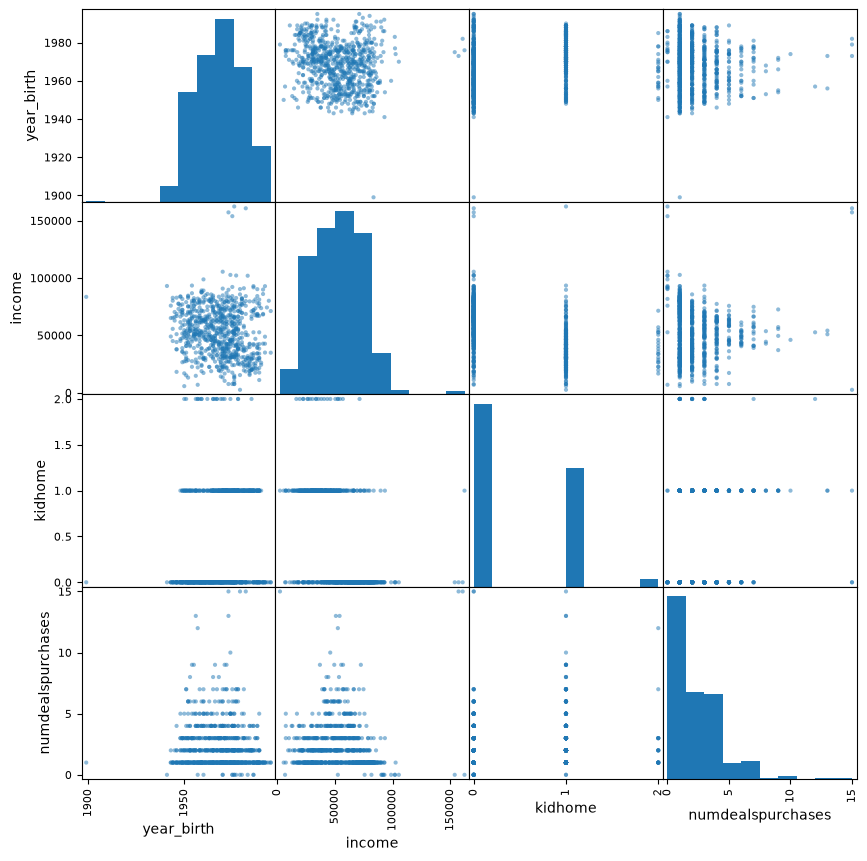

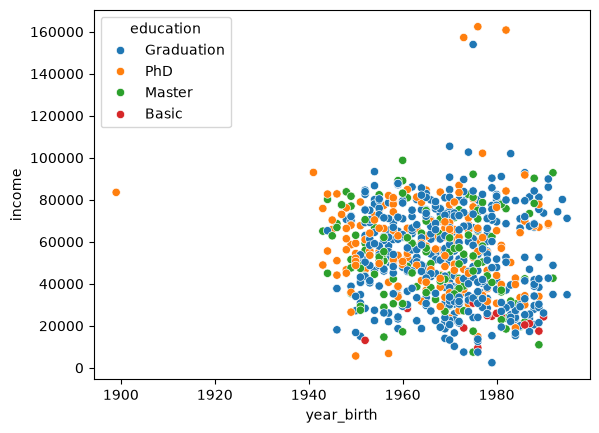

In [5]:
pd.plotting.scatter_matrix(df[['year_birth','income','kidhome','numdealspurchases']], figsize=(10,10), diagonal='hist')
plt.show()
sns.scatterplot(data=df, x='year_birth', y='income', hue='education')
plt.show()


Матрица показывает попарные связи числовых признаков. Категориальная диаграмма позволяет сравнить доходы клиентов разных образовательных групп.


## 3 Гистограммы, корреляция и ковариация


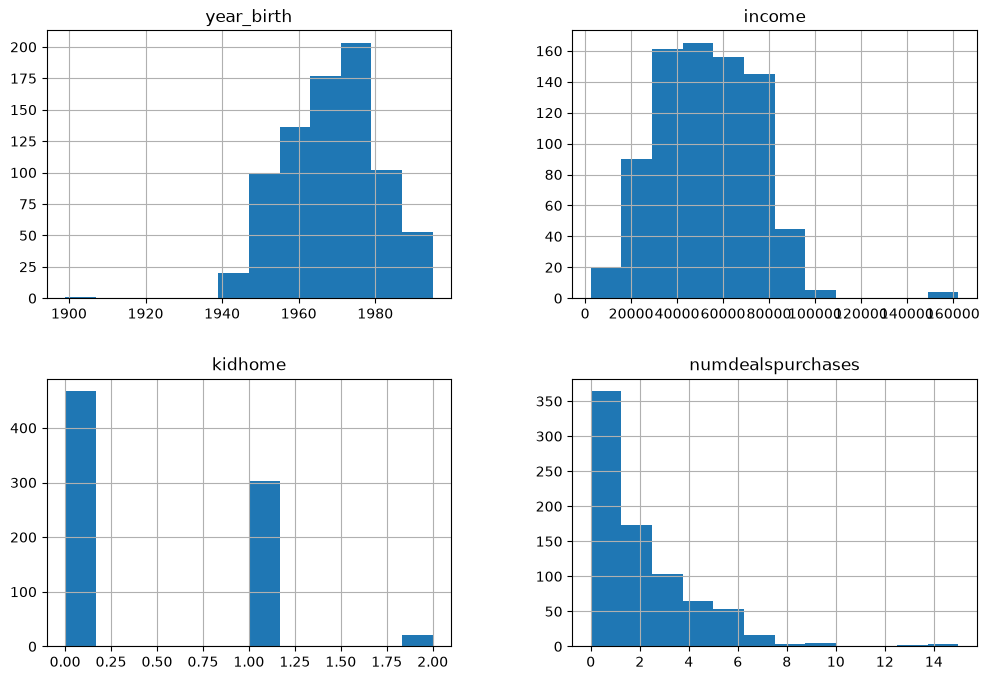

Матрица корреляции:
                   year_birth  income  kidhome  numdealspurchases
year_birth              1.000  -0.143    0.246             -0.061
income                 -0.143   1.000   -0.528             -0.054
kidhome                 0.246  -0.528    1.000              0.198
numdealspurchases      -0.061  -0.054    0.198              1.000
Матрица ковариации:
                   year_birth        income  kidhome  numdealspurchases
year_birth             144.48 -3.728977e+04     1.62              -1.42
income              -37289.77  4.718261e+08 -6279.35           -2263.22
kidhome                  1.62 -6.279350e+03     0.30               0.21
numdealspurchases       -1.42 -2.263220e+03     0.21               3.79


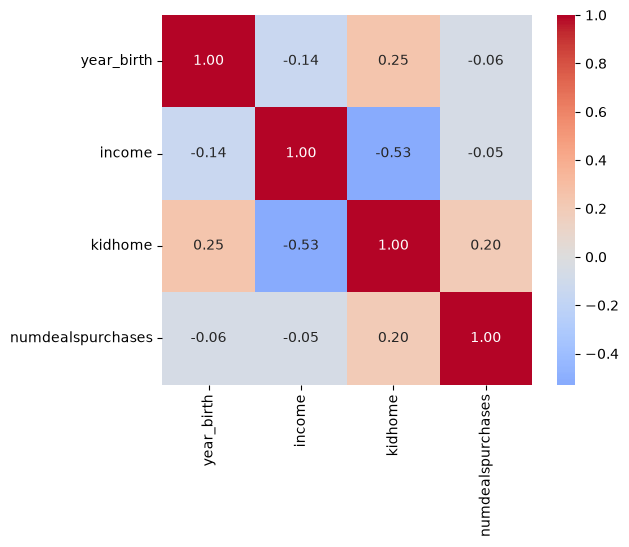

In [6]:
numeric = ['year_birth','income','kidhome','numdealspurchases']
df[numeric].hist(bins=12, figsize=(12,8)); plt.show()
print('Матрица корреляции:')
print(df[numeric].corr().round(3))
print('Матрица ковариации:')
print(df[numeric].cov().round(2))
sns.heatmap(df[numeric].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.show()


## 4 Дополнительные виды графиков


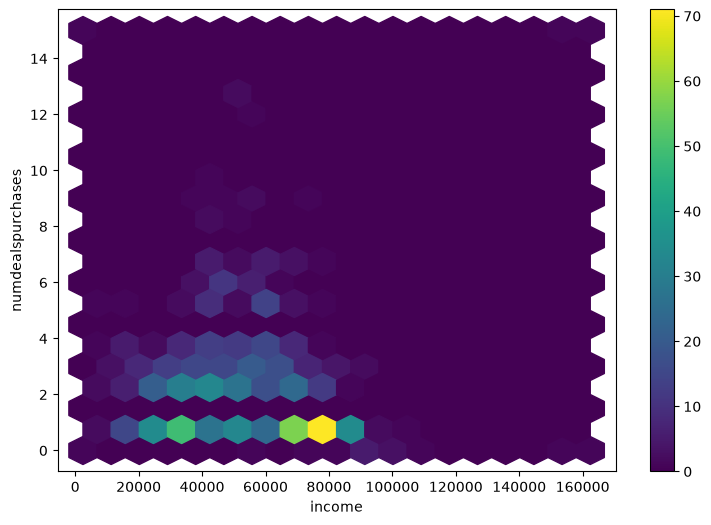

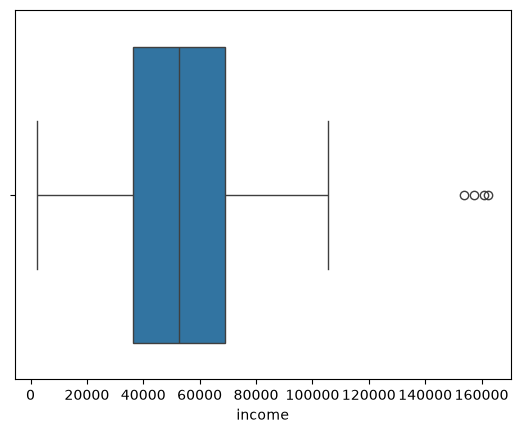

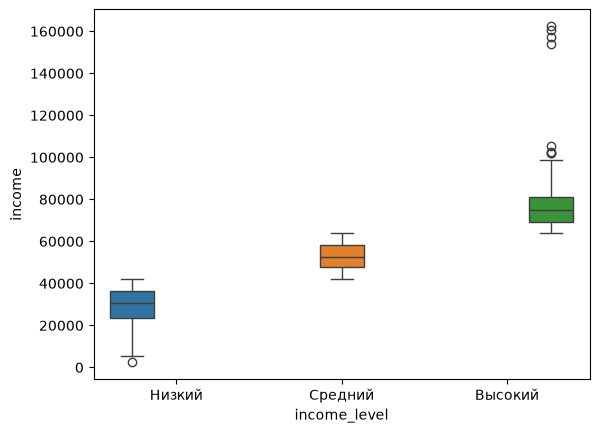

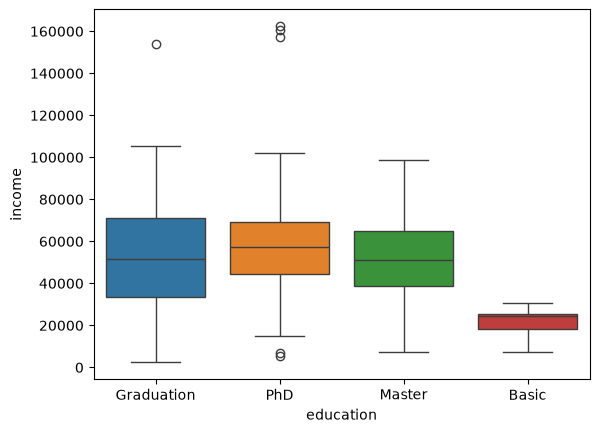

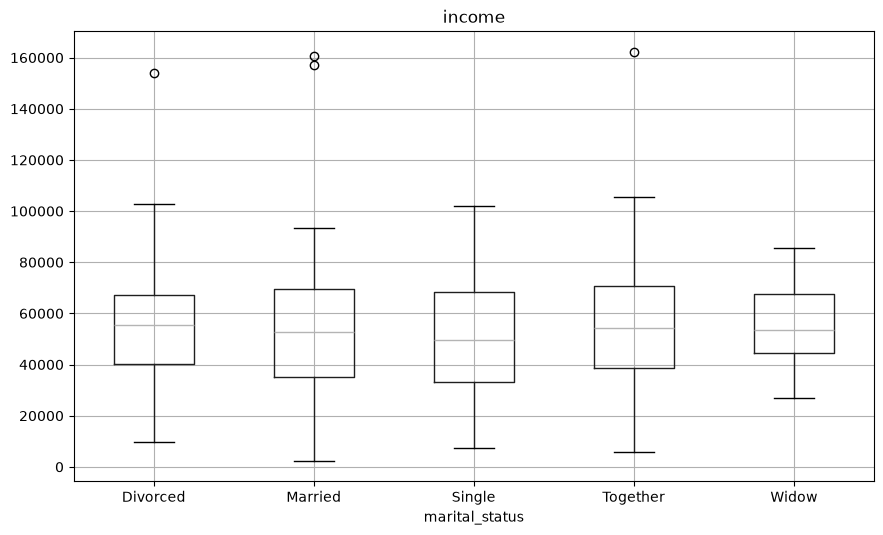

In [7]:
df.plot(x='income', y='numdealspurchases', kind='hexbin', gridsize=18, cmap='viridis', figsize=(9,6), sharex=False)
plt.show()
sns.boxplot(x=df['income']); plt.show()
sns.boxplot(data=df, x='income_level', y='income', hue='income_level', legend=False); plt.show()
sns.boxplot(data=df, x='education', y='income', hue='education', legend=False); plt.show()
df.boxplot(column='income', by='marital_status', figsize=(10,6)); plt.suptitle(''); plt.show()


## 5 Задания варианта 14


     education marital_status  count
0        Basic       Divorced      1
1        Basic        Married      9
2        Basic         Single      1
3        Basic       Together      4
4   Graduation       Divorced     49
5   Graduation        Married    170
6   Graduation         Single    103
7   Graduation       Together     96
8   Graduation          Widow     21
9       Master       Divorced     12
10      Master        Married     57
11      Master         Single     32
12      Master       Together     42
13      Master          Widow      4
14         PhD       Divorced     23
15         PhD        Married     70
16         PhD         Single     42
17         PhD       Together     51
18         PhD          Widow      4


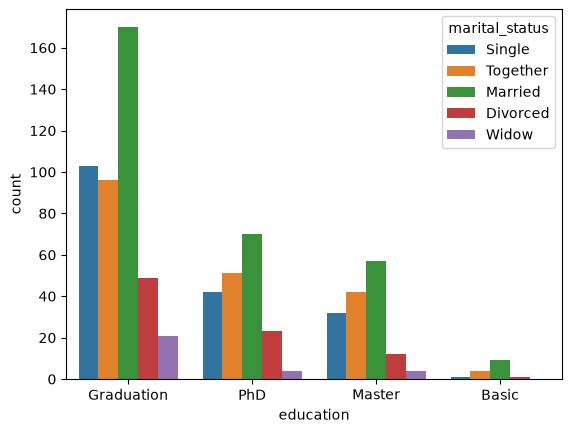

                  income
marital_status          
Divorced        54568.16
Married         52894.63
Single          50990.66
Together        54493.05
Widow           55452.45


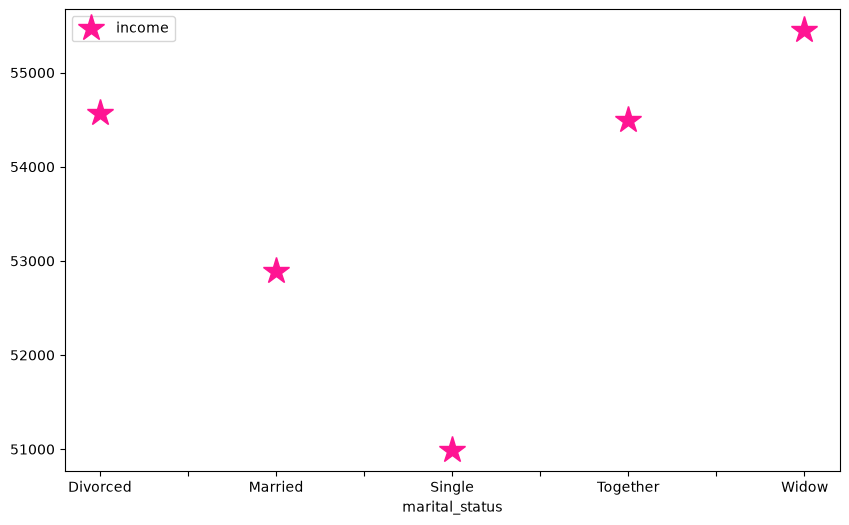

education
Graduation    183
PhD            69
Master         63
Basic           9
Name: count, dtype: int64


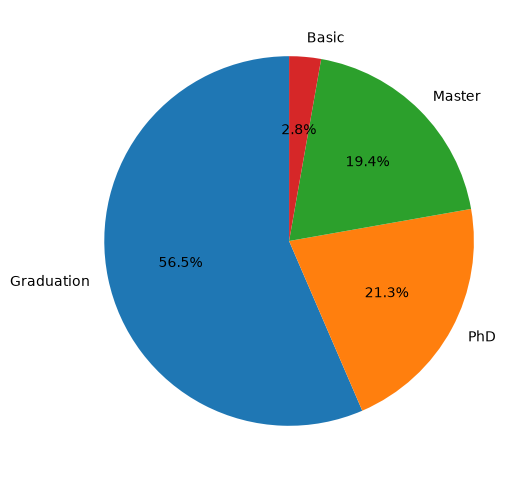

In [8]:
# Задание 1: количество клиентов по образованию и семейному статусу
task1 = df.groupby(['education', 'marital_status']).size().reset_index(name='count')
print(task1)
sns.countplot(data=df, x='education', hue='marital_status'); plt.show()

# Задание 2: средний доход по семейному положению
task2 = df.pivot_table(index='marital_status', values='income', aggfunc='mean').round(2)
print(task2)
task2.plot(kind='line', linestyle='', marker='*', markersize=20, color='deeppink', figsize=(10,6)); plt.show()

# Задание 3: образование клиентов с детьми
task3 = df[df['kidhome'] > 0]['education'].value_counts()
print(task3)
task3.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(10,6)); plt.ylabel(''); plt.show()


## 6 Вывод


После загрузки и очистки данных были обработаны пропуски, дубликаты, категориальные значения и дата регистрации. Распределения доходов и количества покупок изучены с помощью гистограмм и boxplot, а взаимосвязи — с помощью scatter plot, hexbin и матрицы корреляций. Для варианта 14 построены требуемые группировка, сводный график и круговая диаграмма.
